In [97]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [98]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

using device: cpu


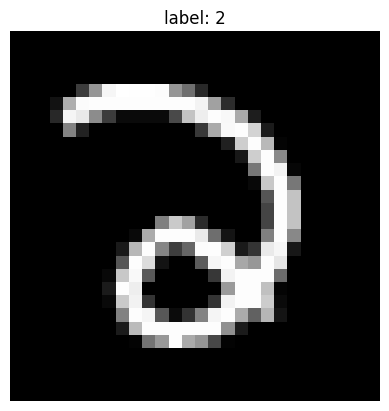

In [99]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# visualize a batch
x, y = next(iter(train_loader))
plt.imshow(x[0][0], cmap='gray')
plt.title(f"label: {y[0].item()}")
plt.axis('off')
plt.show()

# examine dataset

In [100]:
print(f"training data size: {len(train_dataset)}")

training data size: 60000


In [101]:
image, label = train_dataset[0]
print(f"type of image: {type(image)}")
print(f"type of label: {type(label)}")

type of image: <class 'torch.Tensor'>
type of label: <class 'int'>


In [102]:
print(f"image shape: {image.shape}")
print(f"label: {label}")

image shape: torch.Size([1, 28, 28])
label: 5


In [103]:
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=1024):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

In [104]:
model = SparseAutoencoder().to(device)
print(model)

SparseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=1024, out_features=784, bias=True)
    (1): Sigmoid()
  )
)


In [105]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
lambda_sparse = 0.05
epochs = 10

In [106]:
for epoch in range(epochs):
    total_loss = 0
    for x, _ in train_loader:
        x = x.view(x.size(0), -1).to(device)

        optimizer.zero_grad()
        x_hat, z = model(x)

        # reconstruction loss
        recon_loss = criterion(x_hat, x)

        # sparsity penalty
        sparsity_loss = torch.mean(torch.abs(z))

        # total loss 
        loss = recon_loss + lambda_sparse * sparsity_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"epoch: {epoch+1}/{epochs}, loss: {total_loss/len(train_loader):.4f}")

    # monitor sparsity
    with torch.no_grad():
        _, z_sample = model(x[:16])
        active_neurons = (z_sample > 1e-3).float().sum(dim=1)
        print(f"average active neurons per sample: {active_neurons.mean().item():.2f}")

epoch: 1/10, loss: 0.0271
average active neurons per sample: 176.31
epoch: 2/10, loss: 0.0103
average active neurons per sample: 150.69
epoch: 3/10, loss: 0.0082
average active neurons per sample: 154.75
epoch: 4/10, loss: 0.0072
average active neurons per sample: 142.19
epoch: 5/10, loss: 0.0065
average active neurons per sample: 148.94
epoch: 6/10, loss: 0.0060
average active neurons per sample: 146.88
epoch: 7/10, loss: 0.0056
average active neurons per sample: 150.44
epoch: 8/10, loss: 0.0053
average active neurons per sample: 146.81
epoch: 9/10, loss: 0.0050
average active neurons per sample: 156.50
epoch: 10/10, loss: 0.0048
average active neurons per sample: 154.69


# Visualize learned features

In [107]:
weights = model.encoder[0].weight.data.cpu()

In [108]:
weights.shape

torch.Size([1024, 784])

In [109]:
neurons_to_show = 16

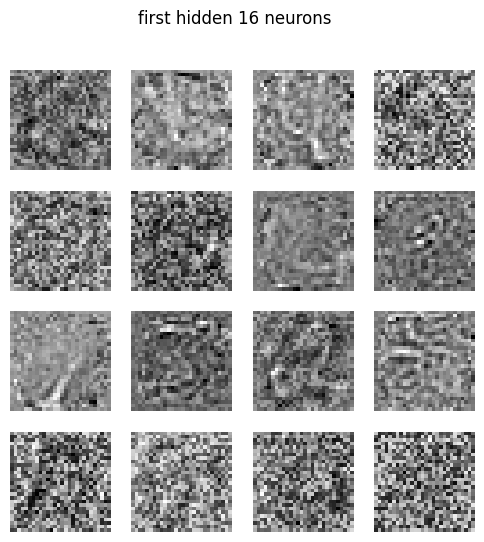

In [110]:
fig, axes = plt.subplots(4, 4, figsize=(6,6))
for i, ax in enumerate(axes.flatten()):
    w = weights[i]
    w = (w - w.min()) / (w.max() - w.min())

    ax.imshow(w.view(28,28), cmap='gray')
    ax.axis('off')
plt.suptitle("first hidden 16 neurons")
plt.show()

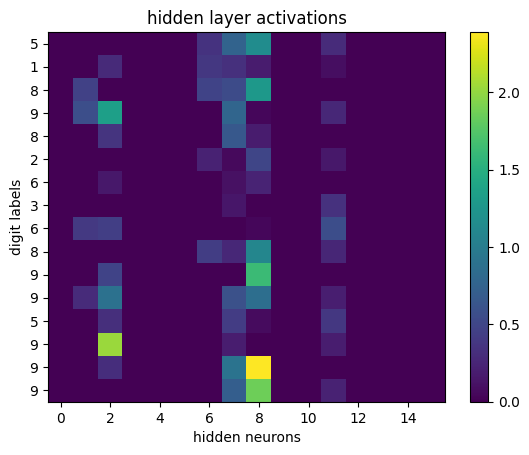

In [111]:
x_batch, labels = next(iter(train_loader))
x_flat = x_batch.view(x_batch.size(0), -1).to(device)

with torch.no_grad():
    _, z = model(x_flat[:16])

z_plot = z[:16, :16].cpu()
labels_np = labels[:16].cpu().numpy()

plt.imshow(z_plot, cmap='viridis', aspect='auto')
plt.yticks(ticks=range(16), labels=labels_np)
plt.xlabel("hidden neurons")
plt.ylabel("digit labels")
plt.title("hidden layer activations")
plt.colorbar()
plt.show()